In [1]:
import os 
import gc

import torch
from torch.optim import Adam

import matplotlib.pyplot as plt

import numpy as np

import subprocess

from datetime import datetime
from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models, create_model_selector
from src.fine_tune.utils import get_device
from src.fine_tune.types import ModelInfo, ModelParameters, TrainingObjects


MODEL_DIR = MODELS / "category_head"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
DINO_DIR = MODELS / "dino_fine_tune"

dino_checkpoints = get_checkpoints(DINO_DIR)

Found 3 checkpoints at /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/dino_fine_tune


In [ ]:
selector = create_model_selector(dino_checkpoints=dino_checkpoints)

selector.display()

Dropdown(description='DINO:', layout=Layout(width='800px'), options=(('Select a DINO model', 'UNSELECTED'), ('…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [5]:
device = get_device()

selected_path = selector.get_selected_path()

pipeline = load_inference_models(selected_path, device=device)

2.12.0+cu130
13.0
True
1
Device: cuda


Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Using pretrained DINOv2 ViT-S/14


In [6]:
%load_ext autoreload
%autoreload 0

from src.fine_tune.model import ProjectionHead

from src.fine_tune import (
    DataLoading,
    contrastive_transform,
    test_transform,
    Trainer,
    TrainLogger,
    load_dataset_meta,
)

from src.fine_tune.losses.unsupervised_head import CombinedLoss, CategoryContLoss, PreservationLoss, VICRegLoss
from src.fine_tune.losses.types import LossCollection, WeightedLoss, LossName

git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()


In [7]:
data = load_dataset_meta(DB_PATH)

meta = data.meta

train_paths = data.train_paths
test_paths = data.test_paths

categories = data.categories

types = data.types

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

In [8]:
NOTES = [
    "Trained using fine-tuned dino"
]

PARAMS: ModelParameters = {
    "seed": 42,
    "num_workers": 0,
    "pin_memory": device.type == "cuda",
    
    "samples_per_category": 32,
    "batch_size": len(categories) * 16, # * samples_per_category
    "epochs": 2,
    "dropout": 0.1,
    "use_residual": False,

    "model_dim": 384,
    "hidden_dim": 1536,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,

    "model_normaliser": "layer",
    "model_name": "model.pt",
}

In [9]:
MODEL_INFO: ModelInfo = {
    "timestamp": timestamp,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : PARAMS,
    "parent_models" : {
        "dino": str(pipeline.dino_stage.path) if pipeline.dino_stage.path is not None else None
    },
    "model_type": "unsupervised_head"
}

In [10]:
loader = DataLoading(root=ROOT, params=PARAMS, categories=categories, types=types)

train_loader, val_loader = loader.create_train_val_loaders(
    train_paths,
    transform=contrastive_transform,
    train_ratio=0.95
)

test_dataset = loader.create_test_dataset(
    test_paths,
    transform=test_transform
)

test_loader = loader.create_test_loader(
    test_dataset,
    excluded_indices=np.empty(0, dtype=np.int64)
)

In [11]:
model = ProjectionHead(dim=PARAMS["model_dim"], hidden_dim=PARAMS["hidden_dim"], norm_type=PARAMS["model_normaliser"]).to(device)

optimizer = Adam(model.parameters(), lr=PARAMS["learning_rate"], weight_decay=PARAMS["weight_decay"])

In [12]:
losses = LossCollection(
    losses=[
        WeightedLoss(
            name=LossName.CATEGORY_CONTRASTIVE,
            loss=CategoryContLoss(temperature=0.1),
            weight=1.0
        ),
        WeightedLoss(
            name=LossName.PRESERVATION,
            loss=PreservationLoss(sim_weight=1, norm_weight=1, eps=1e-8),
            weight=0.5
        ),
        WeightedLoss(
            name=LossName.VICREG,
            loss=VICRegLoss(invar_weight=25, var_weight=25, cov_weight=1, var_target=1),
            weight=1.0
        )
    ]
)

logger = TrainLogger(project="MVTEC OOD", name="Category MLP", model_info=MODEL_INFO)

criterion = CombinedLoss(losses=losses)
criterion.collect_metrics = logger is not None

training_objs = TrainingObjects(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ciaranwhelan245 (ciaranwhelan245-university-of-limerick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [13]:
trainer = Trainer(objs=training_objs, pipeline=pipeline, logger=logger)

results = trainer.train_model(
    epochs=PARAMS["epochs"], 
    train_loader=train_loader,
    val_loader=val_loader
)

try:
    trainer.save_results(
        results=results,
        MODEL_DIR=MODEL_DIR,
        MODEL_INFO=MODEL_INFO,
        timestamp=timestamp
    )

    test_metrics = trainer.test(
        train_loader=train_loader,
        test_loader=test_loader,
        types_to_id=loader.types_to_id
    )
finally:
    if trainer.logger is not None:
        trainer.logger.finish()
    del trainer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if results.error is not None:
    raise results.error

Training:   0%|          | 0/2 [00:00<?, ?it/s]

Output()

Best Model Saved (val_loss=31.1593) as epoch 2


batch/eval/calinski_harabasz,▁
batch/eval/category_contrastive/cosine/different,▁█
batch/eval/category_contrastive/cosine/gap,█▁
batch/eval/category_contrastive/cosine/same,█▁
batch/eval/davies_bouldin,▁
batch/eval/inter_distance,▁
batch/eval/intra_distance,▁
batch/eval/loss/category_contrastive,▁█
batch/eval/loss/preservation,▁█
batch/eval/loss/total,█▁
+272,...


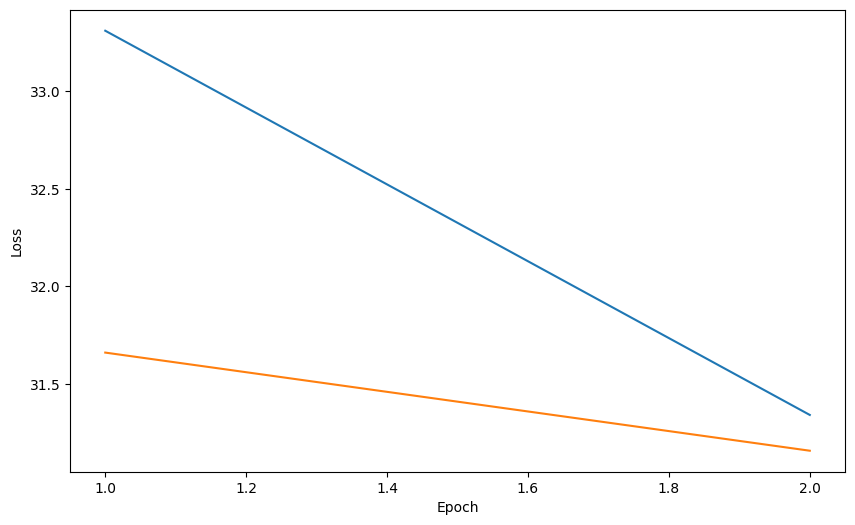

In [14]:
fig = plt.figure(figsize=(10, 6))

plt.plot(results.history["epoch"], results.history["train_loss"])
plt.plot(results.history["epoch"], results.history["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()

In [ ]:
test_metrics

test/category/silhouette                      0.712364
test/category/davies_bouldin                  0.676840
test/category/calinski_harabasz            1074.271126
test/category/intra_distance                  3.290263
test/category/inter_distance                  3.071443
                                              ...     
test/14/normal_defect/davies_bouldin          3.688225
test/14/normal_defect/calinski_harabasz       6.251651
test/14/normal_defect/intra_distance          2.170163
test/14/normal_defect/inter_distance          0.005521
test/14/auroc                                 0.809583
Length: 170, dtype: float64

: 